# 0. About DataSet

# 1. Import & Options

In [28]:
# Sistema
import os
import zipfile

# Principais imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Classificadores
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Arvore de Decisao
from sklearn.ensemble import RandomForestClassifier # Floresta de Decisao
from sklearn.svm import SVC # Support Vector Machine
from xgboost import XGBClassifier # XGBoost
from lightgbm import LGBMClassifier # LGBM
from sklearn.svm import LinearSVC # Linear Support Vector Machine 
from sklearn.dummy import DummyClassifier # Classificador aleatorio
from catboost import CatBoostClassifier # CatBoost

# Avaliadores
from sklearn.metrics import classification_report # Acc, Precision, Recall e F1-Score
from sklearn.metrics import ConfusionMatrixDisplay # Matriz de confusao
from sklearn.metrics import roc_auc_score # area sob curva roc
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, accuracy_score # Metricas
from sklearn.model_selection import cross_val_score # CrossValidation com uma metrica
from sklearn.model_selection import cross_validate # CrossValidation com mais de uma metrica

# Pre processamento
from sklearn.preprocessing import StandardScaler # Normaliza feature media = 0 e desvpad = 1
from sklearn.preprocessing import OneHotEncoder # Encoda uma coluna categorica
from sklearn.impute import SimpleImputer # Imputer: Preenche uma determinada feature
from imblearn.over_sampling import SMOTE # SMOTE

# Datasets nativos SKLearn
from sklearn.datasets import load_digits # Digitos Manuscritos

# DeepLearning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Utilidades
from sklearn.pipeline import make_pipeline # Cria pipeline
from sklearn.pipeline import Pipeline # Executa um pipeline
from sklearn.compose import ColumnTransformer # Aplica transformacoes em colunas
from sklearn.model_selection import train_test_split # Separa treino e teste
from sklearn.model_selection import StratifiedKFold # Estratifica os dados igualmente
from sklearn.model_selection import GridSearchCV

## 1.1. Options

In [29]:
# Parametros Modelos
p_test_size = 0.2
p_valid_size = 0.1
p_random = 210101

# Pandas
pd.set_option('display.max_columns', 100)

# Colors
color_default = 'darkseagreen'

In [30]:
def split(df, t_size, v_size, target, random):
    '''
    df: DataFrame a ser splitado
    t_size: Proporcao do teste
    v_size: Proporcao da Validacao
    target: Variavel target para o stratify
    random: Random state
    '''

    train_df, test_df = train_test_split(df,
                                        test_size = t_size,
                                        random_state = random,
                                        stratify = df[target],
                                        shuffle = True)

    train_df, valid_df = train_test_split(train_df,
                                        test_size = v_size,
                                        random_state = random,
                                        stratify = train_df[target],
                                        shuffle = True)

    print('Observacoes por DataFrame')
    print(f' Treino {train_df.shape[0]}')
    print(f' Validacao {valid_df.shape[0]}')
    print(f' Teste {test_df.shape[0]}')
    print('-----------------------------')
    print('Proporçao dos DataFrames')
    print(f' Treino {round(train_df.shape[0]/df.shape[0], 2)}')
    print(f' Validacao {round(valid_df.shape[0]/df.shape[0], 2)}')
    print(f' Teste {round(test_df.shape[0]/df.shape[0], 2)}')
    
    return train_df, valid_df, test_df

In [31]:
# Crio a funcao que vai calcular as estatisticas
def avalia_modelos(y_true, preds):
    return {
        'Accuracy': accuracy_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'F1 Score': f1_score(y_true, preds),
        'AUC': roc_auc_score(y_true, preds)
    }

# 2. Read Data

In [32]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [33]:
print(f'Quantidade de observacoes: {df.shape[0]}')
print(f'Quantidade de Features: {df.shape[1]}')

Quantidade de observacoes: 891
Quantidade de Features: 15


# 3. Data Exploration

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [35]:
# Presença de Nulls
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [36]:
# Valores distintos por feature categorica
df.select_dtypes(include = 'object').nunique()

sex            2
embarked       3
who            3
embark_town    3
alive          2
dtype: int64

In [37]:
# Transformo algumas features binarias em float
df['adult_male'] = df['adult_male'].astype('float64')
df['alive'] = np.where(df['alive'] == 'yes', 1, 0)
df['alone'] = df['alone'].astype('float64')

In [38]:
df.describe()

,survived,pclass,age,sibsp,parch,fare,adult_male,alive,alone
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.602694,0.383838,0.602694
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.489615,0.486592,0.489615
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,0.000000,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000,1.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000


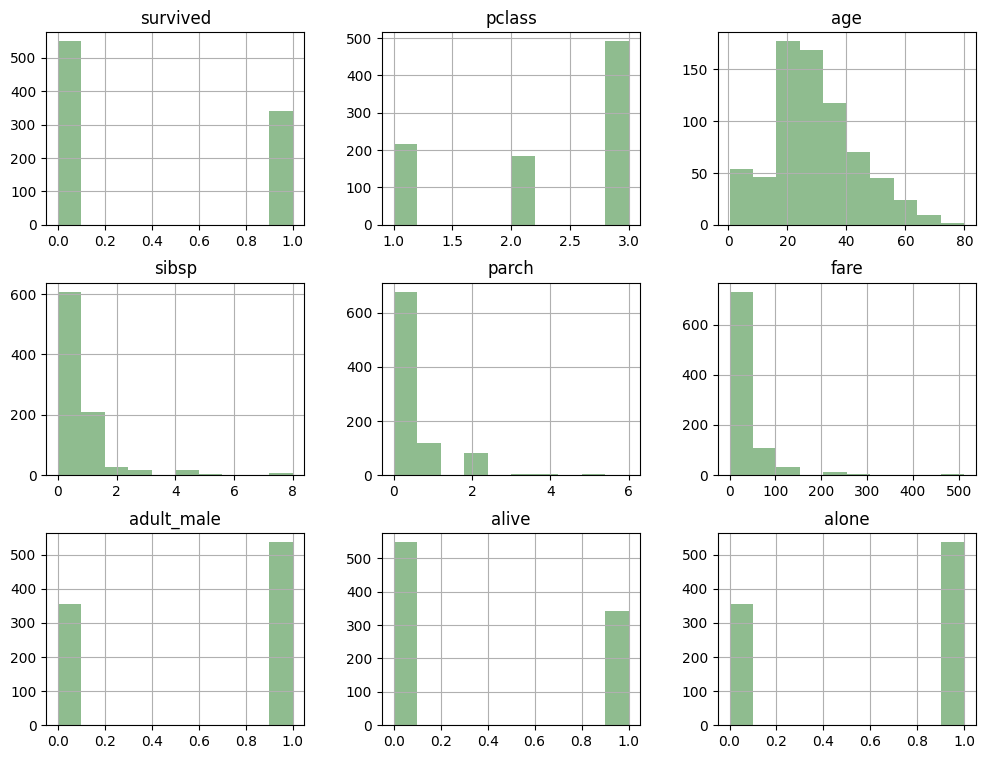

In [39]:
df.hist(figsize = (12, 9),
        color = color_default)
plt.show()

<Axes: >

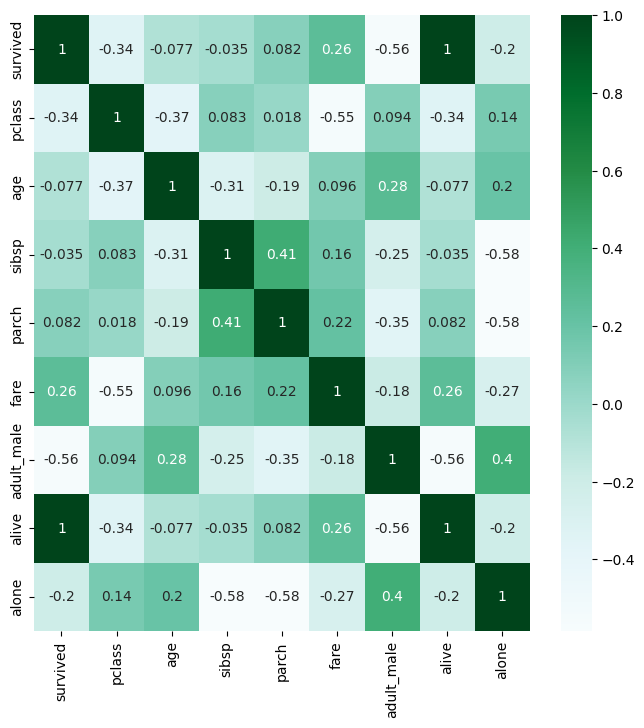

In [40]:
plt.figure(figsize = (8, 8))
corr = np.corrcoef
sns.heatmap(df.select_dtypes(include = 'number').corr(),
            annot = True,
            cmap = 'BuGn')

c:\Users\Caio\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
c:\Users\Caio\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


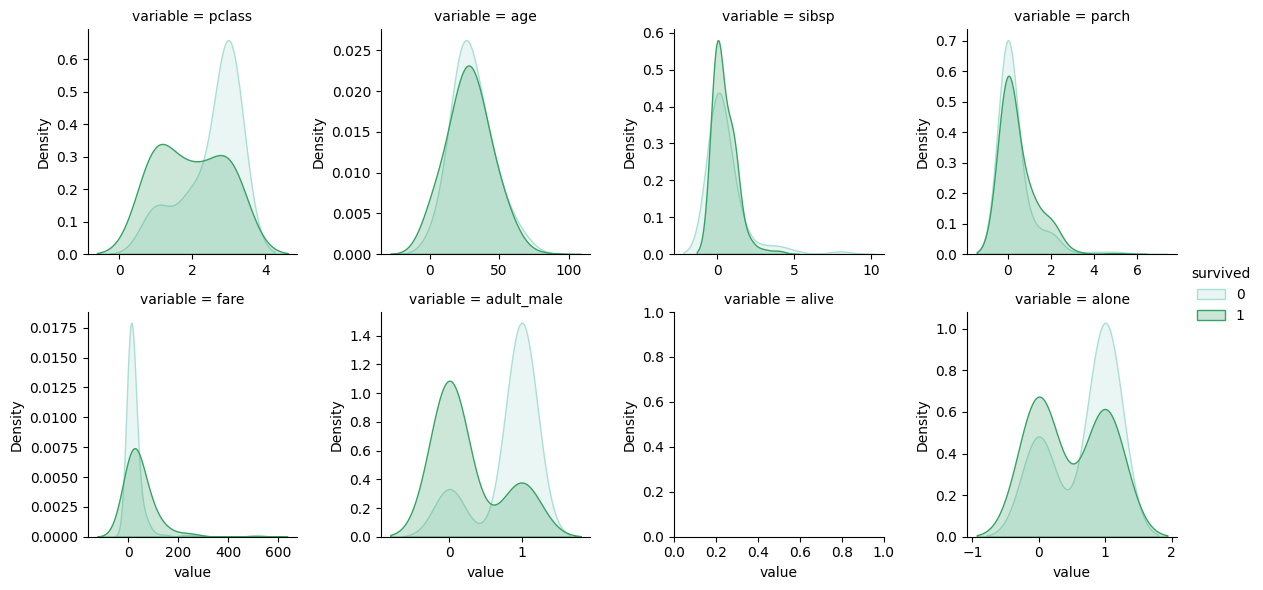

In [41]:
cols = df.select_dtypes(include = 'number').columns

g = sns.FacetGrid(df.melt(id_vars = 'survived',
                          var_name = 'variable',
                          value_name = 'value',
                          value_vars = cols), 
                  col = "variable", 
                  col_wrap = 4, 
                  sharex = False, 
                  sharey = False,
                  height = 3,
                  hue = 'survived',
                  palette = 'BuGn')

g.map(sns.kdeplot, 
      "value", 
      fill = True,
      bw_adjust = 2)

g.add_legend()

plt.show()

    Conclusao

- DataFrame relativamente pequeno (matriz 891x15)
- Presença de features redundantes, alive e survived apresentam os mesmos valores
- Presença de valores nulos no DataFrame

# 4. Split Data

In [42]:
df = df.drop(columns = 'alive')

In [43]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,1.0,NaN,Southampton,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,0.0,C,Cherbourg,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,0.0,NaN,Southampton,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,0.0,C,Southampton,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,1.0,NaN,Southampton,1.0


In [44]:
train_df, valid_df, test_df = split(df, p_test_size, p_valid_size, 'survived', p_random)

Observacoes por DataFrame
 Treino 640
 Validacao 72
 Teste 179
-----------------------------
Proporçao dos DataFrames
 Treino 0.72
 Validacao 0.08
 Teste 0.2


# 5. Preprocessing

In [45]:
# Salvo uma copia dos DFs antes de passar pelo preprocessing
train_df_orig = train_df.copy()
valid_df_orig = valid_df.copy()
test_df_orig = test_df.copy()

col_num = train_df.drop(columns = 'survived').select_dtypes(include = 'number').columns.tolist()
col_cat = train_df.select_dtypes(exclude = 'number').columns.tolist()

# Pipeline para features numericas
pipeline_numerico = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
        ]
    )

# Pipeline para features categoricas
pipeline_categorico = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore',
                                sparse_output=False))
        ]
    )

# Crio o ColumnTransformer com os pipelines
preprocess = ColumnTransformer(
    transformers = [
        ('num', pipeline_numerico, col_num),
       ('cat', pipeline_categorico, col_cat),
    ]
)

# Aplico os pipelines sobre os DFs
X_train_transf = preprocess.fit_transform(train_df)
X_valid_transf = preprocess.transform(valid_df)
X_test_transf = preprocess.transform(test_df)


# Capturo os nomes das colunas categoricas transformadas pelo OneHot
col_cat_out = preprocess.named_transformers_['cat']['onehot'].get_feature_names_out(col_cat)

# Crio um numpy com as colunas pos preprocessamento
col_transf = np.concatenate([col_num, col_cat_out])

# Reconstruindo os DataFrames
# Treino
train_df_transf = pd.DataFrame(X_train_transf, columns = col_transf, index = train_df_orig.index)
train_df_transf['survived'] = train_df_orig['survived']

# Validacao 
valid_df_transf = pd.DataFrame(X_valid_transf, columns = col_transf, index = valid_df_orig.index)
valid_df_transf['survived'] = valid_df_orig['survived']

# Teste
test_df_transf = pd.DataFrame(X_test_transf, columns = col_transf, index = test_df_orig.index)
test_df_transf['survived'] = test_df_orig['survived']

print('Shape Final', 
      '\n',
      f' Treino: {train_df_transf.shape}', 
      '\n',
      f' Validacao: {valid_df_transf.shape}', 
      '\n',
      f' Teste: {test_df_transf.shape}')
print('-----------------------------')
print('Proporçao da target',
      '\n',
      f' Treino: {round(train_df_transf['survived'].sum()/train_df_transf.shape[0], 2)}',
      '\n',
      f' Validacao: {round(valid_df_transf['survived'].sum()/valid_df_transf.shape[0], 2)}',
      '\n',
      f' Teste: {round(test_df_transf['survived'].sum()/test_df_transf.shape[0], 2)}')
print('-----------------------------')
print('Features pos preprocessing',
      '\n',
      col_transf)

Shape Final 
  Treino: (640, 29) 
  Validacao: (72, 29) 
  Teste: (179, 29)
-----------------------------
Proporçao da target 
  Treino: 0.38 
  Validacao: 0.39 
  Teste: 0.39
-----------------------------
Features pos preprocessing 
 ['pclass' 'age' 'sibsp' 'parch' 'fare' 'adult_male' 'alone' 'sex_female'
 'sex_male' 'embarked_C' 'embarked_Q' 'embarked_S' 'class_First'
 'class_Second' 'class_Third' 'who_child' 'who_man' 'who_woman' 'deck_A'
 'deck_B' 'deck_C' 'deck_D' 'deck_E' 'deck_F' 'deck_G'
 'embark_town_Cherbourg' 'embark_town_Queenstown'
 'embark_town_Southampton']


# 6. Predictive Models

## 6.1. Multi Layer Perceptron

In [74]:
# Dimensao de entrada
input_dim = train_df_transf.drop(columns = 'survived').shape[1]

print(f'Features de entrada: {input_dim}')

model = models.Sequential([
    layers.Input(shape=(input_dim,)),      # Layer de entrada
    layers.Dense(32, activation = "tanh"),   # Primeira Layer oculta
    layers.Dropout(0.3),                   # dropout (evita overfitting)
    layers.Dense(32, activation = "tanh"),   # Segunda Layer oculta
    layers.Dense(1, activation = "sigmoid")  # Saida para classificacao binaria com sigmoid
])

model.summary()

Features de entrada: 28


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Compila o modelo
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy', # Funcao de Custo
    metrics = ['accuracy', 'AUC'] # metrica de Avalicao
)

# Early stopping para evitar overfitting
early_stop = callbacks.EarlyStopping(
    monitor = "val_loss",       # Quantity to be monitored. Defaults to "val_loss". 
    patience = 5,               # Para apos 5 epocas sem avancos
    restore_best_weights = True # Se True captura os pesos da melhor epoca
)

# Treinar o modelo
history = model.fit(
    train_df_transf.drop(columns = 'survived'), # Dados do DataFrame de Treino
    train_df_transf['survived'], # Target do DataFrame de Treino
    validation_data = (valid_df_transf.drop(columns = 'survived'), 
                       valid_df_transf['survived']), # DataFrame de Valiacao
    epochs = 50,               # Maximo de epocas
    batch_size = 32,           # Tamanho do batch
    callbacks = [early_stop],
    verbose = 1
)

# Avaliar no conjunto de teste
test_loss, test_acc, test_AUC = model.evaluate(test_df_transf.drop(columns = 'survived'), # Dados do DataFrame de Treino
                                    test_df_transf['survived'], # Target do DataFrame de Treino
                                    verbose = 0)
print(f'Loss no teste: {test_loss:.4f}')
print(f'Acurácia no teste: {test_acc:.4f}')
print(f'AUC no teste: {test_AUC:.4f}')

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.7068 - accuracy: 0.6734 - loss: 0.6221 - val_AUC: 0.8653 - val_accuracy: 0.8472 - val_loss: 0.4799
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8198 - accuracy: 0.7812 - loss: 0.5002 - val_AUC: 0.8730 - val_accuracy: 0.8472 - val_loss: 0.4231
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8402 - accuracy: 0.7969 - loss: 0.4696 - val_AUC: 0.8750 - val_accuracy: 0.8333 - val_loss: 0.4170
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8579 - accuracy: 0.8078 - loss: 0.4425 - val_AUC: 0.8770 - val_accuracy: 0.8333 - val_loss: 0.4121
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8602 - accuracy: 0.8172 - loss: 0.4382 - val_AUC: 0.8847 - val_accuracy: 0.8333 - val_loss: 0.4053
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8552 - accuracy: 0.8016 - loss: 0.4437 - val_AUC: 0.8799 - val_accuracy: 0.8472 - val_loss: 0.4075
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

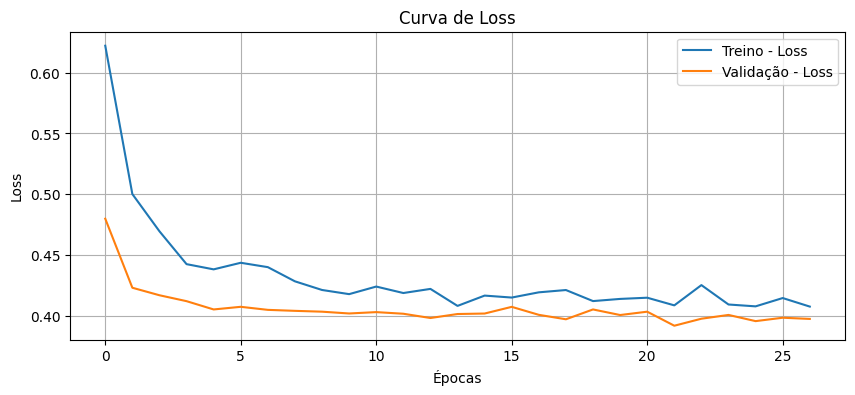

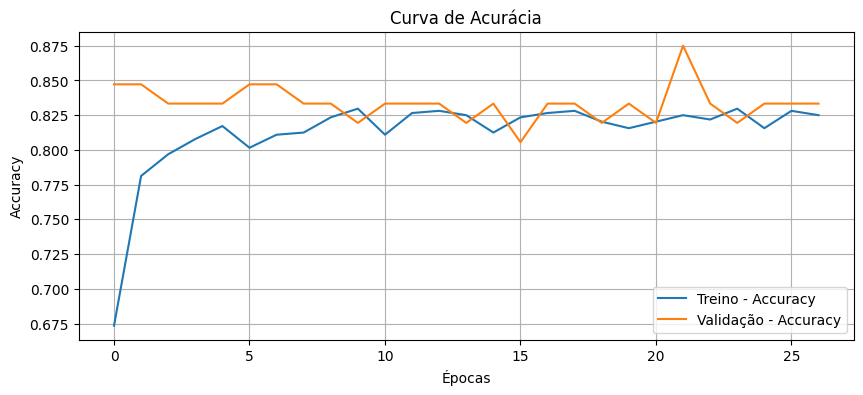

In [76]:
import matplotlib.pyplot as plt

# Histórico
history_dict = history.history

# Loss
plt.figure(figsize = (10, 4))
plt.plot(history_dict['loss'], label = 'Treino - Loss')
plt.plot(history_dict['val_loss'], label = 'Validação - Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curva de Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure(figsize = (10, 4))
plt.plot(history_dict['accuracy'], label = 'Treino - Accuracy')
plt.plot(history_dict['val_accuracy'], label = 'Validação - Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Curva de Acurácia')
plt.legend()
plt.grid(True)
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


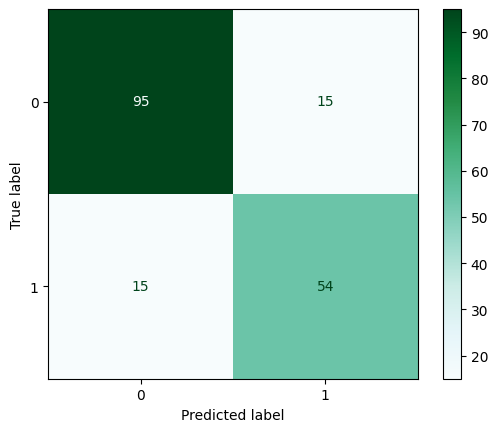

In [77]:
# Faço predict d
preds_mlp = model.predict(test_df_transf.drop(columns = 'survived'))
preds_mlp = (preds_mlp > 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(test_df_transf['survived'].values, 
                                        preds_mlp,
                                        cmap = 'BuGn')
plt.show()

In [78]:
avalia_modelos(test_df_transf['survived'], preds_mlp)

{'Accuracy': 0.8324022346368715,
 'Recall': 0.782608695652174,
 'Precision': 0.782608695652174,
 'F1 Score': 0.782608695652174,
 'AUC': 0.8231225296442688}

## 6.2. RandomForest

In [79]:
clf_rf = RandomForestClassifier(n_estimators = 50, # Default = 100
                    criterion = 'gini', # Default = 'gini'
                    max_depth = 3, # Default = None
                    random_state = p_random,
                    n_jobs = -1,
                    verbose = False)

clf_rf.fit(train_df_transf.drop(columns = 'survived'),
           train_df_transf['survived'].values)

,n_estimators,50
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
preds_rf = clf_rf.predict(test_df_transf.drop(columns = 'survived'))

avalia_modelos(test_df_transf['survived'], preds_rf)

{'Accuracy': 0.8268156424581006,
 'Recall': 0.7101449275362319,
 'Precision': 0.8166666666666667,
 'F1 Score': 0.7596899224806202,
 'AUC': 0.8050724637681159}

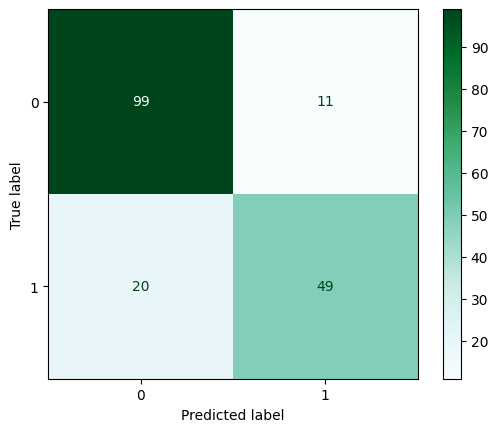

In [81]:
ConfusionMatrixDisplay.from_predictions(test_df_transf['survived'].values, 
                                        preds_rf,
                                        cmap = 'BuGn')
plt.show()